In [1]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob, Word

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("Mental-Health-Twitter.csv")
df.head()

,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1
3,3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1
4,4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1


In [3]:
!pip install textblob nltk

Defaulting to user installation because normal site-packages is not writeable


In [4]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [5]:
df.shape

(20000, 11)

In [6]:
df.isnull().sum() # check for missing values

Unnamed: 0      0
post_id         0
post_created    0
post_text       0
user_id         0
followers       0
friends         0
favourites      0
statuses        0
retweets        0
label           0
dtype: int64

In [7]:
# keep only the required columns
df = df[['post_text']]
df.head()

,post_text
0,It's just over 2 years since I was diagnosed w...
1,"It's Sunday, I need a break, so I'm planning t..."
2,Awake but tired. I need to sleep but my brain ...
3,RT @SewHQ: #Retro bears make perfect gifts and...
4,It’s hard to say whether packing lists are mak...


In [8]:
df.describe()

,post_text
count,20000
unique,19488
top,Oh crap! It's a trap! Aleph took damage.
freq,15


In [9]:
df.shape

(20000, 1)

In [10]:
# Stopwords
sw = stopwords.words("english")


# Text Cleaning Function
def clean_text(text):

    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Remove stopwords
    text = " ".join(
        word for word in text.split()
        if word not in sw
    )

    # Lemmatization
    text = " ".join(
        Word(word).lemmatize()
        for word in text.split()
    )

    return text


# Apply cleaning
df["clean_text"] = df["post_text"].apply(clean_text)

print(df[["post_text", "clean_text"]].head())

                                           post_text  \
0  It's just over 2 years since I was diagnosed w...   
1  It's Sunday, I need a break, so I'm planning t...   
2  Awake but tired. I need to sleep but my brain ...   
3  RT @SewHQ: #Retro bears make perfect gifts and...   
4  It’s hard to say whether packing lists are mak...   

                                          clean_text  
0  year since diagnosed anxiety depression today ...  
1  sunday need break im planning spend little tim...  
2                  awake tired need sleep brain idea  
3  rt sewhq retro bear make perfect gift great be...  
4  hard say whether packing list making life easi...  


In [11]:
df["tokens"] = df["clean_text"].apply(
    lambda x: TextBlob(x).words
)

print(df[["clean_text", "tokens"]].head())

                                          clean_text  \
0  year since diagnosed anxiety depression today ...   
1  sunday need break im planning spend little tim...   
2                  awake tired need sleep brain idea   
3  rt sewhq retro bear make perfect gift great be...   
4  hard say whether packing list making life easi...   

                                              tokens  
0  [year, since, diagnosed, anxiety, depression, ...  
1  [sunday, need, break, im, planning, spend, lit...  
2           [awake, tired, need, sleep, brain, idea]  
3  [rt, sewhq, retro, bear, make, perfect, gift, ...  
4  [hard, say, whether, packing, list, making, li...  


Import TextBlob and NLTK (Natural Language Toolkit) which are used for natural language processing (NLP) tasks.

TextBlob provides a more user-friendly API for common NLP tasks such as sentiment analysis, part-of-speech tagging, and text classification.

NLTK provides a wide range of functionalities for tasks such as tokenization, stemming, lemmatization, parsing, and more. It also includes a vast array of corpora and datasets for language modeling and machine learning.

In [12]:
# Get polarity
df["polarity"] = df["clean_text"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

print(df[["clean_text", "polarity"]].head())

                                          clean_text  polarity
0  year since diagnosed anxiety depression today ...  0.100000
1  sunday need break im planning spend little tim... -0.093750
2                  awake tired need sleep brain idea -0.400000
3  rt sewhq retro bear make perfect gift great be...  0.900000
4  hard say whether packing list making life easi... -0.045833


Lemmatization and Word tokenization

In [13]:
df["Sentiment"] = np.where(
    df["polarity"] >= 0,
    "Positive",
    "Negative"
)

print(df[["clean_text", "polarity", "Sentiment"]].head())

                                          clean_text  polarity Sentiment
0  year since diagnosed anxiety depression today ...  0.100000  Positive
1  sunday need break im planning spend little tim... -0.093750  Negative
2                  awake tired need sleep brain idea -0.400000  Negative
3  rt sewhq retro bear make perfect gift great be...  0.900000  Positive
4  hard say whether packing list making life easi... -0.045833  Negative


In [12]:
# Lemmatization (to group similar words together)
from textblob import Word
nltk.download("wordnet")
nltk.download("omw-1.4")
df["post_text"] = df["post_text"].apply(lambda x: " ".join([Word(x).lemmatize()]))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [13]:
!pip install spacy
!python -m spacy download en_core_web_sm
!pip install -U NLTK

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 2.3 MB/s eta 0:00:06
     ---- ----------------------------------- 1.3/12.8 MB 2.5 MB/s eta 0:00:05
     ----- ---------------------------------- 1.8/12.8 MB 2.5 MB/s eta 0:00:05
     ------- -------------------------------- 2.4/12.8 MB 2.5 MB/s eta 0:00:05
     --------- ------------------------------ 2.9/12.8 MB 2.5 MB/s eta 0:00:04
     ---------- ----------------------------- 3.4/12.8 MB 2.5 MB/s eta 0:00:04
     ------------ --------------------------- 3.9/12.8 MB 2.5 MB/s eta 0:00:04
     ------------- -------------------------- 4.5/12.8 MB 2.5 MB/s eta 0:00:04
     --------------- ------------------------ 5.0/12.8 MB 2.5 MB/s e

In [14]:
# tokenize each word
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')p
from nltk.tokenize import word_tokenize
df["tokens"] = df["post_text"].apply(lambda x: TextBlob(x).words)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [15]:
df.head()

,post_text,tokens
0,years since diagnosed anxiety depression today...,"[years, since, diagnosed, anxiety, depression,..."
1,sunday need break im planning spend little tim...,"[sunday, need, break, im, planning, spend, lit..."
2,awake tired need sleep brain ideas,"[awake, tired, need, sleep, brain, ideas]"
3,rt sewhq retro bears make perfect gifts great ...,"[rt, sewhq, retro, bears, make, perfect, gifts..."
4,hard say whether packing lists making life eas...,"[hard, say, whether, packing, lists, making, l..."


Sentiment Analysis
We will employ TextBlob, a Python library, to conduct sentiment analysis on our preprocessed text data. The objective is to classify each tweet as either exhibiting signs of depression or not, based on its sentiment score. Sentiment analysis is an NLP technique that entails analyzing the emotional tone of text, with the goal of automatically classifying it as positive, negative, or neutral, depending on the words and phrases used. TextBlob utilizes a machine learning algorithm to analyze text and assign a sentiment score ranging from -1 to +1, where a score of -1 indicates a very negative sentiment, +1 indicates a very positive sentiment, and 0 indicates a neutral sentiment. By analyzing tweets using TextBlob's sentiment analysis, we can categorize them as depressed or non-depressed based on their sentiment scores. For example, a tweet with a sentiment score of -0.8 might be classified as depressed, while a tweet with a sentiment score of +0.5 may be classified as non-depressed.

In [14]:
# Applying sentiment to entire dataset

blob_emptylist = []

for i in df["post_text"]:
    blob = TextBlob(i).sentiment # returns polarity
    blob_emptylist.append(blob)

In [15]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(
    df["clean_text"]
)

y = df["Sentiment"]

print("\nVector Shape :", X.shape)


Vector Shape : (20000, 31336)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)

print("Testing Data :", X_test.shape)

Training Data : (16000, 31336)
Testing Data : (4000, 31336)


In [17]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train, y_train)

print("KNN Model Trained Successfully")

KNN Model Trained Successfully


In [18]:
y_pred = knn.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "\nModel Accuracy :",
    round(accuracy * 100, 2),
    "%"
)


Model Accuracy : 84.15 %


In [22]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)


Classification Report:

              precision    recall  f1-score   support

    Negative       0.79      0.17      0.28       727
    Positive       0.84      0.99      0.91      3273

    accuracy                           0.84      4000
   macro avg       0.82      0.58      0.60      4000
weighted avg       0.83      0.84      0.80      4000



In [23]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:\n")

print(cm)


Confusion Matrix:

[[ 126  601]
 [  33 3240]]


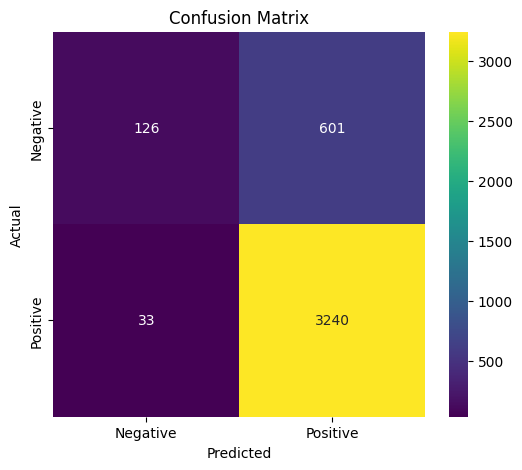

In [24]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
while True:

    user_text = input(
        "\nEnter a tweet/document (type 'exit' to stop): "
    )

    # Exit condition
    if user_text.lower() == "exit":

        print("\nProgram Ended.")

        break

    # Clean user text
    cleaned = clean_text(user_text)

    # Convert text into vector
    vector_input = vectorizer.transform(
        [cleaned]
    )

    # Predict sentiment
    prediction = knn.predict(
        vector_input
    )

    print(
        "\nCleaned Text :",
        cleaned
    )

    print(
        "Predicted Sentiment :",
        prediction[0]
    )


Enter a tweet/document (type 'exit' to stop):  Happy



Cleaned Text : happy
Predicted Sentiment : Positive



Enter a tweet/document (type 'exit' to stop):  Not sad



Cleaned Text : sad
Predicted Sentiment : Positive



Enter a tweet/document (type 'exit' to stop):  beautiful



Cleaned Text : beautiful
Predicted Sentiment : Positive


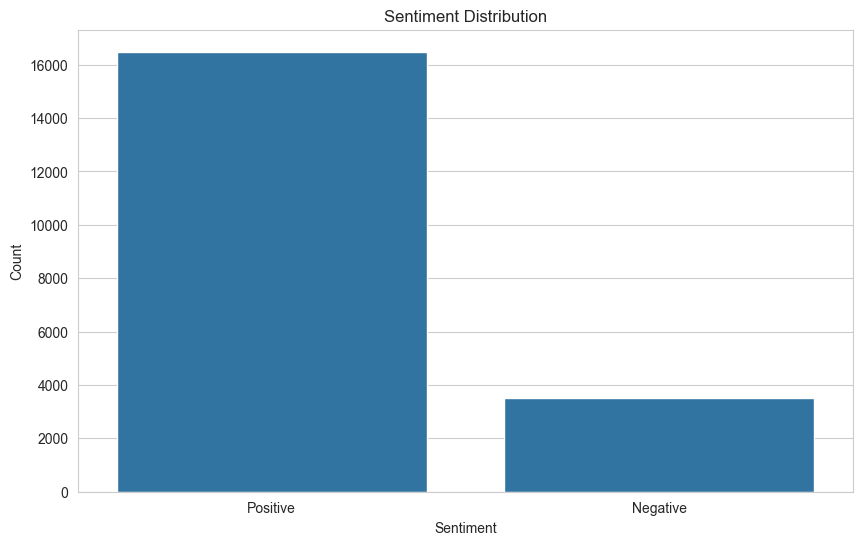

In [25]:
# Visualize distribution of sentiment
plt.figure(figsize=(10,6))
sns.countplot(x='Sentiment', data=df4,order=df4['Sentiment'].value_counts().index)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Distribution')
plt.show()

**KNN Classifier**

In [27]:
# split the data into test and train set
X_train, X_test, y_train, y_test = train_test_split(df4['post_text'], df4['Sentiment'], test_size=0.2, random_state=42)

In [28]:
# Convert the text data into numerical features using a CountVectorizer
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [29]:
# create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [30]:
# Evaluate the classifier on the testing set
accuracy = knn.score(X_test, y_test)
print('Accuracy:', accuracy)

Accuracy: 0.843


In [31]:
# Get the accuracy score of the model
print('The accuracy of the KNN Classifier is',round(accuracy_score(knn.predict(X_test), y_test)*100,2),'%')

The accuracy of the KNN Classifier is 84.3 %


In [32]:
# Create a classification report
print(classification_report(y_test, knn.predict(X_test)))

              precision    recall  f1-score   support

    Negative       0.78      0.17      0.28       718
    Positive       0.85      0.99      0.91      3282

    accuracy                           0.84      4000
   macro avg       0.82      0.58      0.60      4000
weighted avg       0.83      0.84      0.80      4000



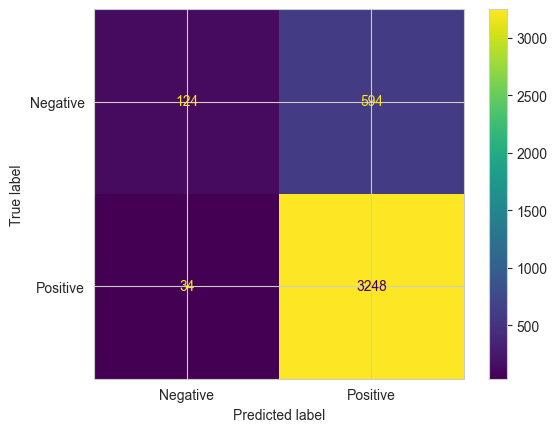

In [33]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, knn.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot()